In [ ]:
import os 
import math 
from typing import  Literal ,Dict,List,Any
from typing_extensions import  TypedDict
from pydantic import  BaseModel,Field
from langgraph.graph import  StateGraph,START,END,MessagesState 
from langchain_core.messages import  HumanMessage,BaseMessage
from langgraph.prebuilt import  ToolNode
from langchain_groq import ChatGroq
from langchain_core.tools import  tool
from dotenv import  load_dotenv



: 

In [ ]:
load_dotenv()
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="meta-llama/llama-prompt-guard-2-22m")

In [48]:
class Clinical_state(MessagesState):
    patient_vitals:Dict[str,Any]
    risk_score:float
    next_node:str

In [49]:
class Superviser(MessagesState):
    """the superviser manage all the agents and work in the cordination also in the best loop """
    next_node:Literal["validation_agent", "cardio_ml_worker", "reporting_worker", "FINISH"]=Field(
        discription="Route to validation if vitals are missing, cardio if data is ready, reporting if risk is calculated.")


C:\Users\Malik\AppData\Local\Temp\ipykernel_8712\4189312931.py:3: PydanticDeprecatedSince20: Using extra keyword arguments on `Field` is deprecated and will be removed. Use `json_schema_extra` instead. (Extra keys: 'discription'). Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  next_node:Literal["validation_agent", "cardio_ml_worker", "reporting_worker", "FINISH"]=Field(


In [50]:
@tool
def vec_db(patient:str)->str:
    """Search vector database for historical patient vitals."""
    rec={
        "khan": "Historical vitals: age 55, previous cholesterol 245, max heart rate 140.",
        "azmat": "Historical vitals: age 42, previous cholesterol 190, max heart rate 165."
    }
    
    return rec.get(patient,"no rec found")

@tool
def search_clinical_literature(symptom: str) -> str:
    """Query external literature for symptom risk factors."""
    if "chest pain" in symptom.lower():
        return "Literature indicates atypical angina combined with cholesterol > 240 increases risk."
    return "No significant recent literature flags for this symptom."


    
tools=[vec_db,search_clinical_literature]

t_llm=llm.bind_tools(tools)


In [51]:
# react agent and routing

def react_Agent(state:Clinical_state):
    sys_prompt = (     
        "You are a clinical intake agent. Use tools to gather full patient history. "
        "Once you have gathered the data, summarize it and stop using tools.")
    messages=[{"role":"system","content":sys_prompt}]+ state["messages"]
    resp= t_llm.invoke(messages)
    
    # Make sure this says "messages", not "message"!
    return {"messages": [resp]} 


def router(state:Clinical_state)->Literal["tools","supervisornode"]:
    lastmsg=state["messages"][-1]
    
    # Safely check if the attribute exists before trying to read it
    if hasattr(lastmsg, 'tool_calls') and lastmsg.tool_calls:
        return "tools"
        
    return "supervisornode"    
   

In [52]:
def supervisor_node (state:Clinical_state):
    sys_prompt=("You are the Clinical Triage Supervisor. Review the conversation history.\n"
    "- If vitals are NOT cleanly extracted into a dictionary, route to 'validation_agent'.\n"
    "- If vitals are extracted but risk_score is 0.0, route to 'cardio_ml_worker'.\n"
    "- If risk_score is calculated, route to 'reporting_worker'.")
    message= [{"role":"system","content":sys_prompt}]+state["messages"]
    decision= llm.with_structured_output(router).invoke(message)
    return{"next_node":decision.next_node}    
def validationagent(state:Clinical_state):
    """Parses text to extract a clean dictionary of features."""
    cleaned_vitals={"age":55,"chol":245,"thalach":140}
    return{
        "patient_vitals":cleaned_vitals,
        "messages":[{"role": "assistant", "content": "Vitals strictly validated and formatted."}]
    }
def calculate_gauss_prob(x:float,mean:float ,stdev:float)->float:
    """mathimatical implimantation of the gaussian PDF from scratch"""
    if stdev==0.0:
        stdev = 1e-9
    exponent=math.exp(-((x-mean)**2/(2*stdev**2)))
    return (1 / (math.sqrt(2 * math.pi) * stdev)) * exponent    
def cardio_ml_worker(state:Clinical_state):
    """executes the classical ML prediction pipeline"""
    vitals=state.get("patient_vitals",{})
    age=vitals.get("age",50)
    chol=vitals.get("chol",200)
    mean_age ,std_age=54.0,9.0
    mean_chol,std_chol=250.0,40.0
    probage=calculate_gauss_prob(age,mean_age,std_age)
    probchol=calculate_gauss_prob(chol,mean_chol,std_chol)
    risk_score=round(probage*probchol*1000,4)
    return{
        "risk_score":risk_score,
    "messages":[{"role":"assistant","content":f"Gaussian ML risk score calculated: {risk_score}"}]
    }


def reporting_worker(state: Clinical_state):
    """Formats the final payload for the Streamlit UI."""
    vitals = state.get("patient_vitals", {})
    score = state.get("risk_score", 0.0)
    report = f"FINAL DIAGNOSTIC PAYLOAD:\n- Vitals: {vitals}\n- Calculated Gaussian Risk Score: {score}"
    return {"messages": [{"role": "assistant", "content": report}]}   
        

In [53]:
graph=StateGraph(Clinical_state)

In [54]:
graph.add_node("reactagent",react_Agent)
graph.add_node("tools",ToolNode(tools))
graph.add_node("cardiomlworker",cardio_ml_worker)
graph.add_node("supervisornode",supervisor_node)
graph.add_node("reportingworker",reporting_worker)
graph.add_node("validation_Agent",validationagent)

In [55]:

# routing 
graph.add_edge(START,"reactagent")
graph.add_conditional_edges("reactagent", router)

graph.add_edge("tools","reactagent")

In [56]:
graph.add_edge("validation_Agent","supervisornode")
graph.add_edge("reportingworker","supervisornode")
graph.add_edge("cardiomlworker","supervisornode")

In [57]:
graph.add_conditional_edges(
        "supervisornode",
        lambda state:state["next_node"],{

         "validation_Agent": "validation_Agent",
        "cardiomlworker": "cardiomlworker",
        "reportingworker": "reportingworker",
        "FINISH": END


        }

)

In [58]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


app=graph.compile(checkpointer=memory)



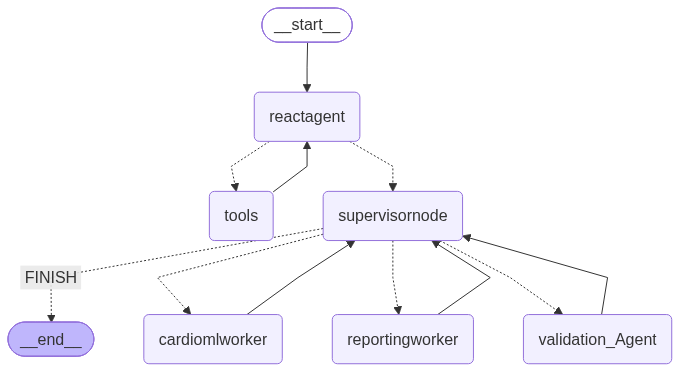

In [59]:
app

In [60]:
initial_input = "Patient khan is experiencing chest pain."
config={"configurable":{"thread_id":"session-1"}}   
result = app.invoke({
    "messages": [HumanMessage(content=initial_input)],
    "patient_vitals": {},
    "risk_score": 0.0,
    "next_node": ""
    } ,config=config)
    
for msg in result["messages"]:
    print(f"{msg.role.upper()}: {msg.content}\n")


APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01kq7299vkeajbwprhxxndjyrc` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8257, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}